# Projet Fondement IA — Analyse de la Personnalité Client


**Dataset :** `personnalité client_bruité.csv`  
**Objectif :** Analyser, nettoyer et modéliser un jeu de données clients afin de comprendre les profils de personnalité et prédire le comportement d'achat

---

## Sommaire
1. Introduction et contexte métier
2. Importation des librairies
3. Chargement et exploration initiale des données
4. Nettoyage et traitement du bruit (données bruitées)
5. Analyse exploratoire des données (EDA)
6. Feature Engineering
7. Préparation des données pour la modélisation
8. Apprentissage non-supervisé — Segmentation client (Clustering)
9. Apprentissage supervisé — Prédiction de la réponse client
10. Évaluation et comparaison des modèles
11. Interprétation des résultats
12. Conclusion et perspectives

## 1. Introduction et contexte métier

### 1.1 Présentation du problème
Une entreprise souhaite mieux comprendre ses clients pour personnaliser ses campagnes marketing et améliorer son taux de conversion.*

### 1.2 Description du jeu de données
*Présenter brièvement les variables :*
- **Démographie :** `Year_Birth`, `Education`, `Marital_Status`, `Income`, `Kidhome`, `Teenhome`
- **Ancienneté :** `Dt_Customer`, `Recency`
- **Dépenses (2 ans) :** `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds`
- **Canaux d'achat :** `NumDealsPurchases`, `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`, `NumWebVisitsMonth`
- **Campagnes :** `AcceptedCmp1`...`AcceptedCmp5`, `Response` (cible), `Complain`

### 1.3 Objectifs
- Nettoyer un dataset bruité
- Réaliser une analyse exploratoire approfondie
- Segmenter les clients en profils types (clustering)
- Prédire la variable cible `Response` (classification supervisée)
- Comparer plusieurs modèles et justifier le meilleur

## 2. Importation des librairies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, silhouette_score, roc_curve,
)


## 3. Chargement et exploration initiale des données

### 3.1 Chargement du fichier CSV


In [6]:

# Chaque ligne du CSV est entourée de guillemets ("..."), ce qui empêche
# pandas de découper correctement sur la tabulation.
with open("personnalité client_bruité.csv", "r", encoding="utf-8") as f:
    contenu = f.read().replace('"', '')

df = pd.read_csv(StringIO(contenu), sep="\t")



### 3.2 Dimensions et types des variables


In [8]:
print("Taille du dataset :") 
print(df.shape)
print("Types des variables :")
print(df.dtypes)
print("Informations sur le dataset :")
print(df.info())


Taille du dataset :
(2240, 29)
Types des variables :
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                float64
MntWines               float64
MntFruits                int64
MntMeatProducts        float64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds           float64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object
Informations sur le dataset :
<cla

In [9]:
print("Aperçu des données :" )
print(df.head())

Aperçu des données :
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012     58.0     635.0  ...                  7             0   
1  08-03-2014      NaN      11.0  ...                  5             0   
2  21-08-2013     26.0     426.0  ...                  4             0   
3  10-02-2014     26.0      11.0  ...                  6             0   
4  19-01-2014     94.0     173.0  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Compla

### 3.3 Statistiques descriptives

In [11]:
print("Statistiques descriptives :")
print(df.describe())


Statistiques descriptives :
                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   2240.000000  2240.000000    2216.000000  2240.000000  2240.000000   
mean    5592.159821  1968.805804   52247.251354     0.444196     0.506250   
std     3246.662198    11.984069   25173.076661     0.538398     0.544538   
min        0.000000  1893.000000    1730.000000     0.000000     0.000000   
25%     2828.250000  1959.000000   35303.000000     0.000000     0.000000   
50%     5458.500000  1970.000000   51381.500000     0.000000     0.000000   
75%     8427.750000  1977.000000   68522.000000     1.000000     1.000000   
max    11191.000000  1996.000000  666666.000000     2.000000     2.000000   

           Recency     MntWines    MntFruits  MntMeatProducts  \
count  2239.000000  2239.000000  2240.000000      2239.000000   
mean     49.114337   303.899955    26.302232       167.019652   
std      28.967970   336.668329    39.773434       225.741716   
min       0.000000

### 3.4 Premier diagnostic du bruit


In [13]:

#print("Valeurs manquantes :")
#print(df.isnull().sum())
print("pourcentage de valeurs manquantes :")
print(df.isnull().mean() * 100)

#la colonne Income etant a 1% de valeurs manquantes, on la garde. 

pourcentage de valeurs manquantes :
ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.044643
MntWines               0.044643
MntFruits              0.000000
MntMeatProducts        0.044643
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.044643
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
dtype: float64


In [14]:

print("Doublons :")
print(df.duplicated().sum())


Doublons :
0


In [15]:

print("Modalités douteuses :")
for col in df.columns:
    print(f"{col} : {df[col].unique()}")


Modalités douteuses :
ID : [5524 2174 4141 ... 7270 8235 9405]
Year_Birth : [1957 1954 1965 1984 1981 1967 1971 1985 1974 1950 1983 1976 1959 1952
 1987 1946 1980 1949 1982 1979 1951 1969 1986 1989 1963 1970 1973 1943
 1975 1996 1968 1964 1977 1978 1955 1966 1988 1948 1958 1972 1960 1945
 1991 1962 1953 1961 1956 1992 1900 1893 1990 1947 1899 1993 1994 1941
 1944 1995 1940]
Education : ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Marital_Status : ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']
Income : [58138. 46344. 71613. ... 56981. 69245. 52869.]
Kidhome : [0 1 2]
Teenhome : [0 1 2]
Dt_Customer : ['04-09-2012' '08-03-2014' '21-08-2013' '10-02-2014' '19-01-2014'
 '09-09-2013' '13-11-2012' '08-05-2013' '06-06-2013' '13-03-2014'
 '15-11-2013' '10-10-2012' '24-11-2012' '24-12-2012' '31-08-2012'
 '28-03-2013' '03-11-2012' '08-08-2012' '06-01-2013' '23-12-2012'
 '11-01-2014' '18-03-2013' '02-01-2013' '27-05-2013' '20-02-2013'
 '31-05-2013' '22-11-2013' '22-0

## 4. Nettoyage et traitement du bruit

### 4.1 Suppression des doublons
On retire les lignes strictement identiques pour éviter de biaiser les statistiques et les modèles.

In [17]:
avant = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Doublons supprimés : {avant - df.shape[0]} | Nouvelle taille : {df.shape}")


Doublons supprimés : 0 | Nouvelle taille : (2240, 29)


### 4.2 Gestion des valeurs manquantes
Seule la colonne `Income` contient des NaN (~1 %). Comme la distribution des revenus est asymétrique (longue traîne à droite), on impute par la **médiane**, plus robuste que la moyenne aux hauts revenus. Par sécurité, on applique la même logique aux autres colonnes numériques, et le **mode** aux colonnes catégorielles.

In [19]:
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("NaN restants :", df.isna().sum().sum())


NaN restants : 0


### 4.3 Correction des modalités catégorielles
Les colonnes `Education` et `Marital_Status` contiennent des valeurs incohérentes (casse, espaces, modalités absurdes comme `YOLO` ou `Absurd`). On harmonise puis on regroupe :

- `Marital_Status` → **Single** (Single, Alone, Widow, Divorced, Yolo, Absurd) / **Together** (Married, Together)
- `Education` → **Undergraduate** (Basic, 2n Cycle) / **Graduate** (Graduation) / **Postgraduate** (Master, PhD)

Ce regroupement réduit le bruit et évite des catégories quasi-vides après encodage.

In [21]:
df["Marital_Status"] = df["Marital_Status"].str.strip().str.title()
df["Education"] = df["Education"].str.strip().str.title()

df["Marital_Status"] = df["Marital_Status"].replace({
    "Yolo": "Single", "Absurd": "Single", "Alone": "Single",
    "Widow": "Single", "Divorced": "Single", "Married": "Together",
})

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2N Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "Phd": "Postgraduate",
})

print("Marital_Status :", df["Marital_Status"].unique())
print("Education      :", df["Education"].unique())


Marital_Status : ['Single' 'Together']
Education      : ['Graduate' 'Postgraduate' 'Undergraduate']


### 4.4 Détection et traitement des outliers
Les boxplots révèlent quelques valeurs aberrantes manifestement irréalistes. On applique des **seuils métier** simples :

- `Year_Birth >= 1940` (un client ne peut pas avoir plus de 85 ans environ)
- `Income < 200 000 €` (revenu annuel extrême peu plausible)


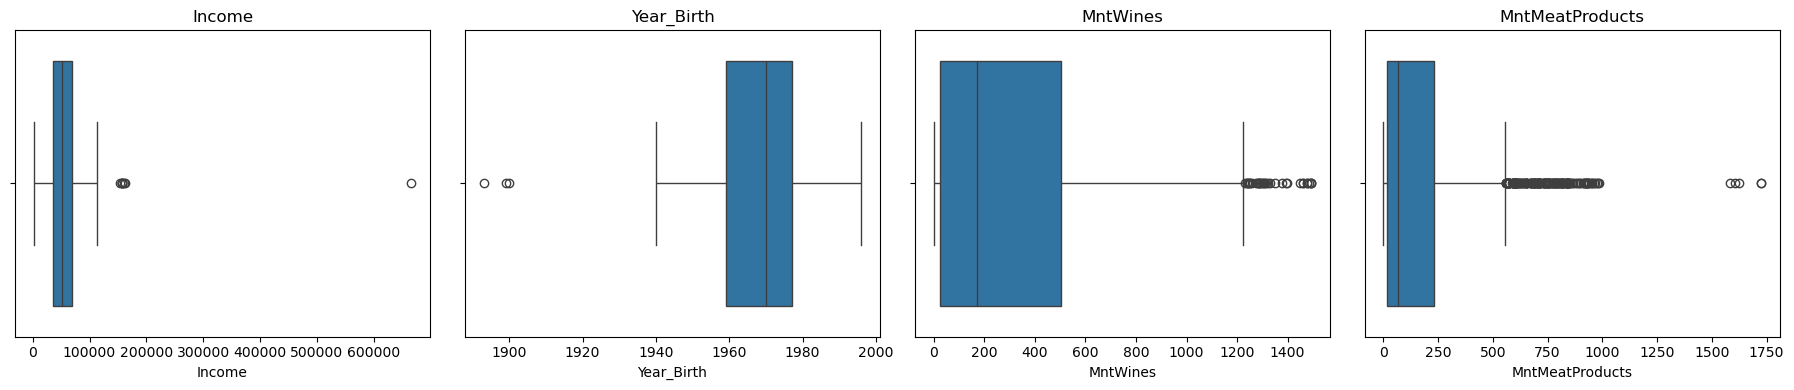

Lignes supprimées : 4 | Nouvelle taille : (2236, 29)


In [23]:
cols_outliers = ["Income", "Year_Birth", "MntWines", "MntMeatProducts"]

fig, axes = plt.subplots(1, len(cols_outliers), figsize=(18, 4))
for ax, col in zip(axes, cols_outliers):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

avant = df.shape[0]
df = df[(df["Year_Birth"] >= 1940) & (df["Income"] < 200_000)].reset_index(drop=True)
print(f"Lignes supprimées : {avant - df.shape[0]} | Nouvelle taille : {df.shape}")


### 4.5 Conversion des types et suppression des colonnes inutiles
- `Dt_Customer` converti en `datetime` (format `jj-mm-aaaa`) pour pouvoir calculer l'ancienneté plus tard.
- `Z_CostContact` et `Z_Revenue` sont constantes → on les supprime.
- `ID` est un identifiant unique sans valeur prédictive → supprimé.

In [25]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")
df = df.drop(columns=[c for c in ["Z_CostContact", "Z_Revenue", "ID"] if c in df.columns])

print(f"Dimensions finales : {df.shape}")
print(df.dtypes)


Dimensions finales : (2236, 26)
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                       float64
MntWines                      float64
MntFruits                       int64
MntMeatProducts               float64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                  float64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Response          

## 5. Analyse exploratoire des données (EDA)

### 5.1 Distribution des variables numériques


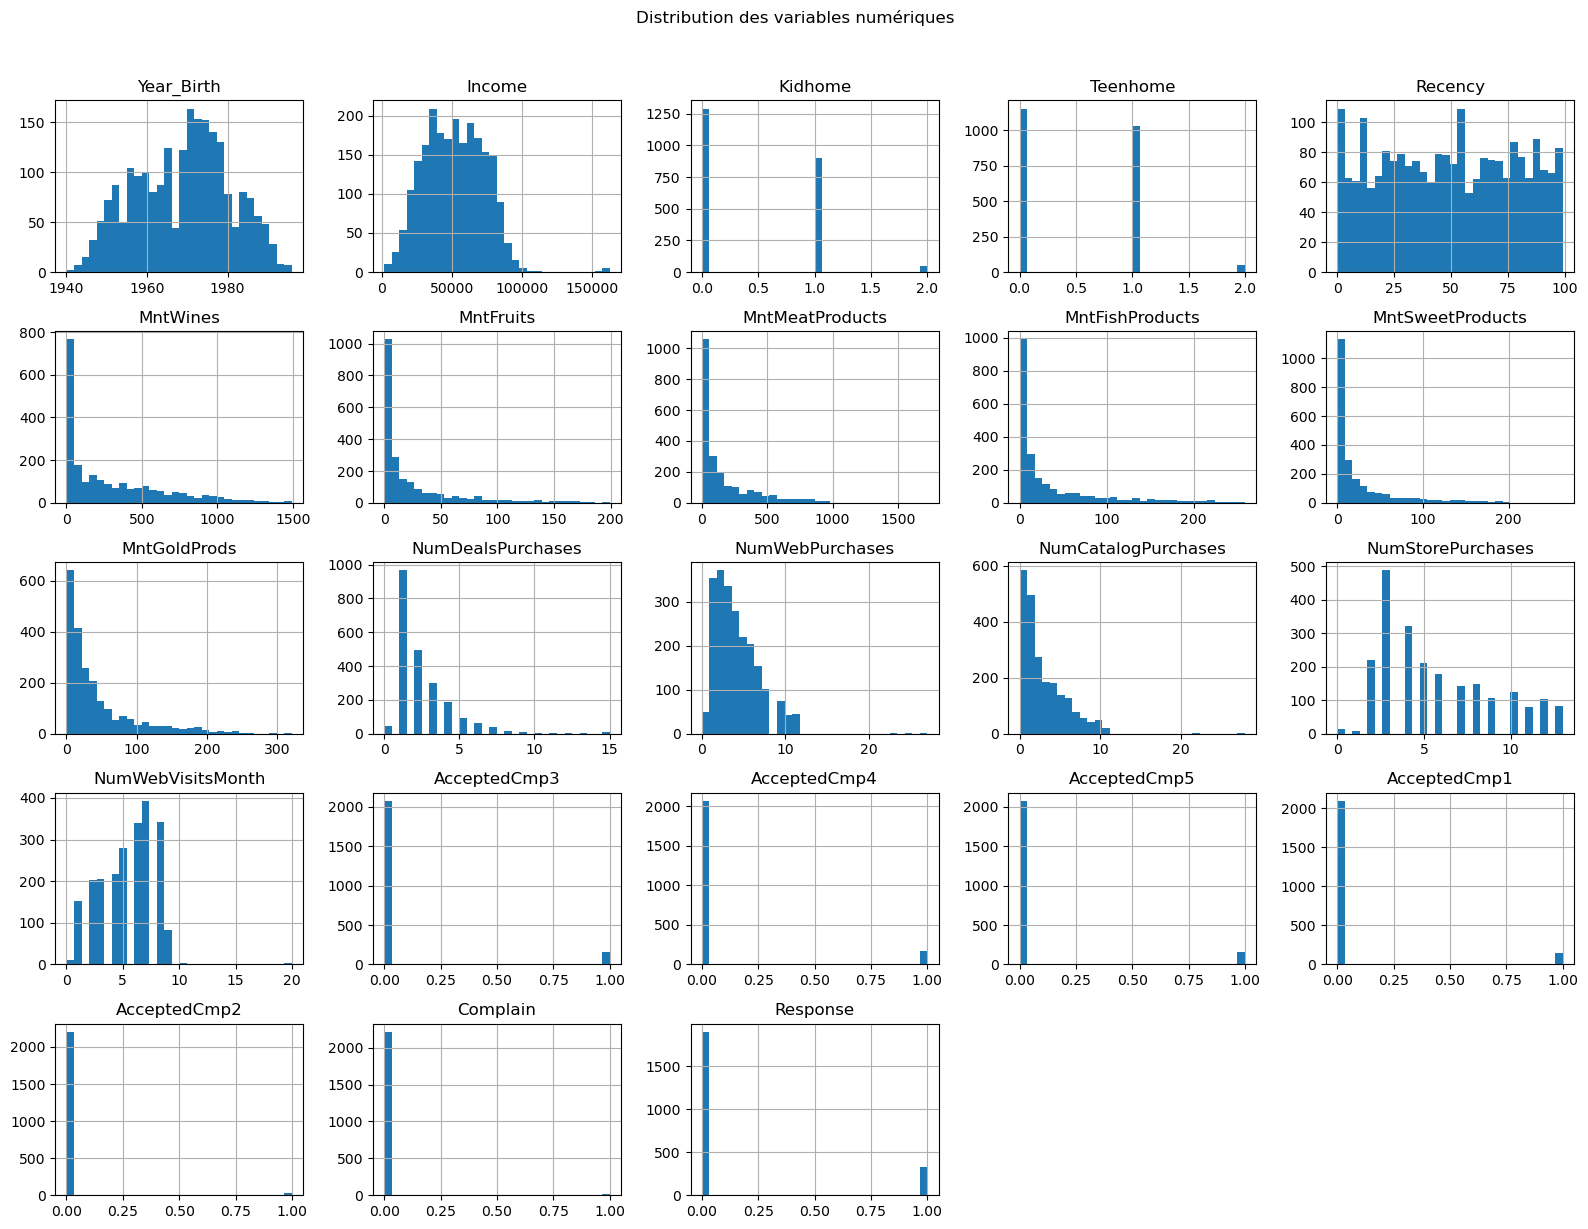

In [27]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution des variables numériques", y=1.02)
plt.tight_layout()
plt.show()


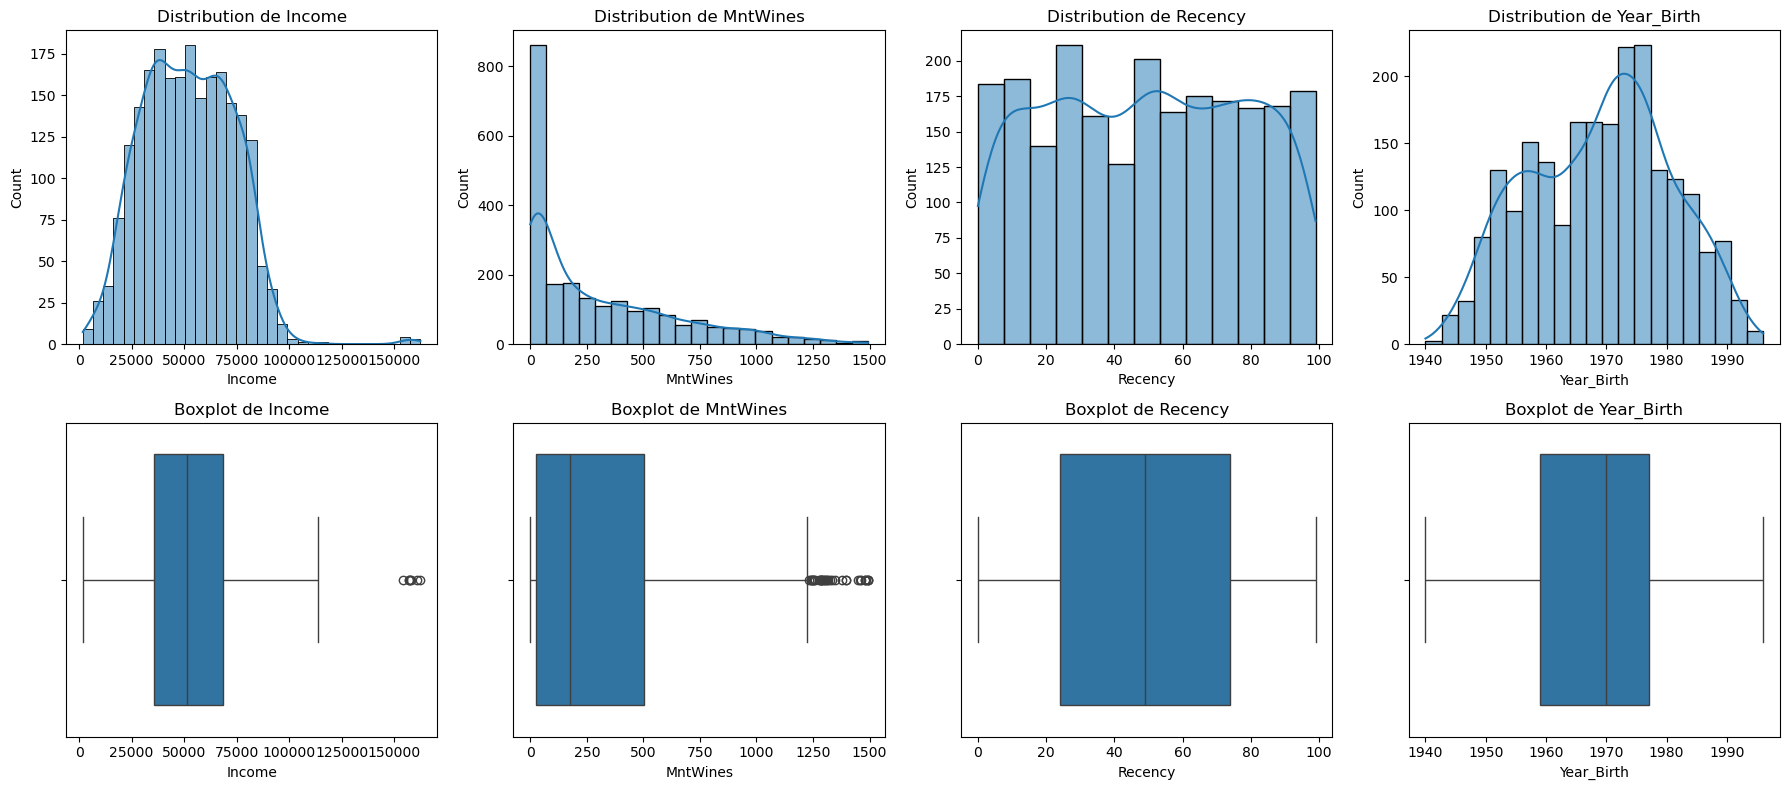

In [28]:

variables = ["Income", "MntWines", "Recency", "Year_Birth"]

fig, axes = plt.subplots(2, len(variables), figsize=(18, 8))
for i, col in enumerate(variables):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"Distribution de {col}")
    sns.boxplot(x=df[col], ax=axes[1, i])
    axes[1, i].set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()


### 5.2 Distribution des variables catégorielles
*Diagrammes en barres pour `Education`, `Marital_Status`, `Response`.*

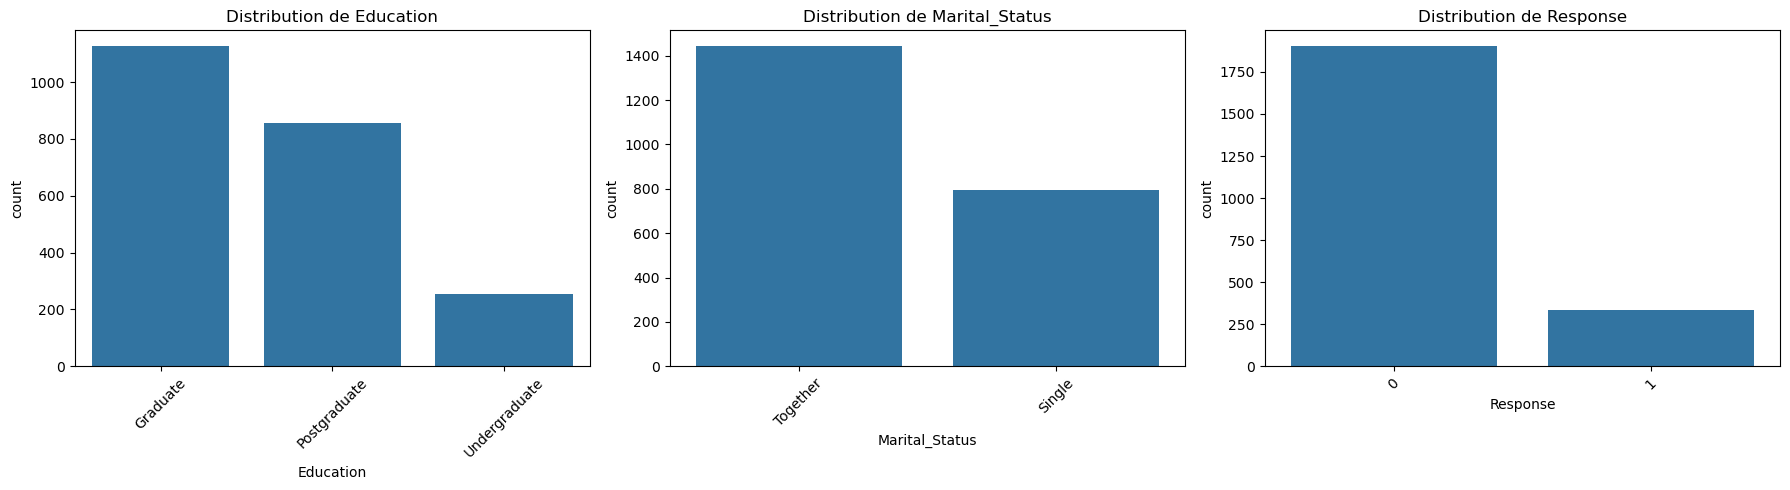

In [30]:

cat_cols = ["Education", "Marital_Status", "Response"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=df, ax=ax,
                  order=df[col].value_counts().index)
    ax.set_title(f"Distribution de {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


> **Observations :** la majorité des clients sont en couple (Together) et de niveau Graduate. La cible Response est très **déséquilibrée** (~85 % de 0 / 15 % de 1) 

### 5.3 Analyse bivariée et matrice de corrélation
*Heatmap des corrélations, pairplots, relations entre `Income` et les dépenses.*

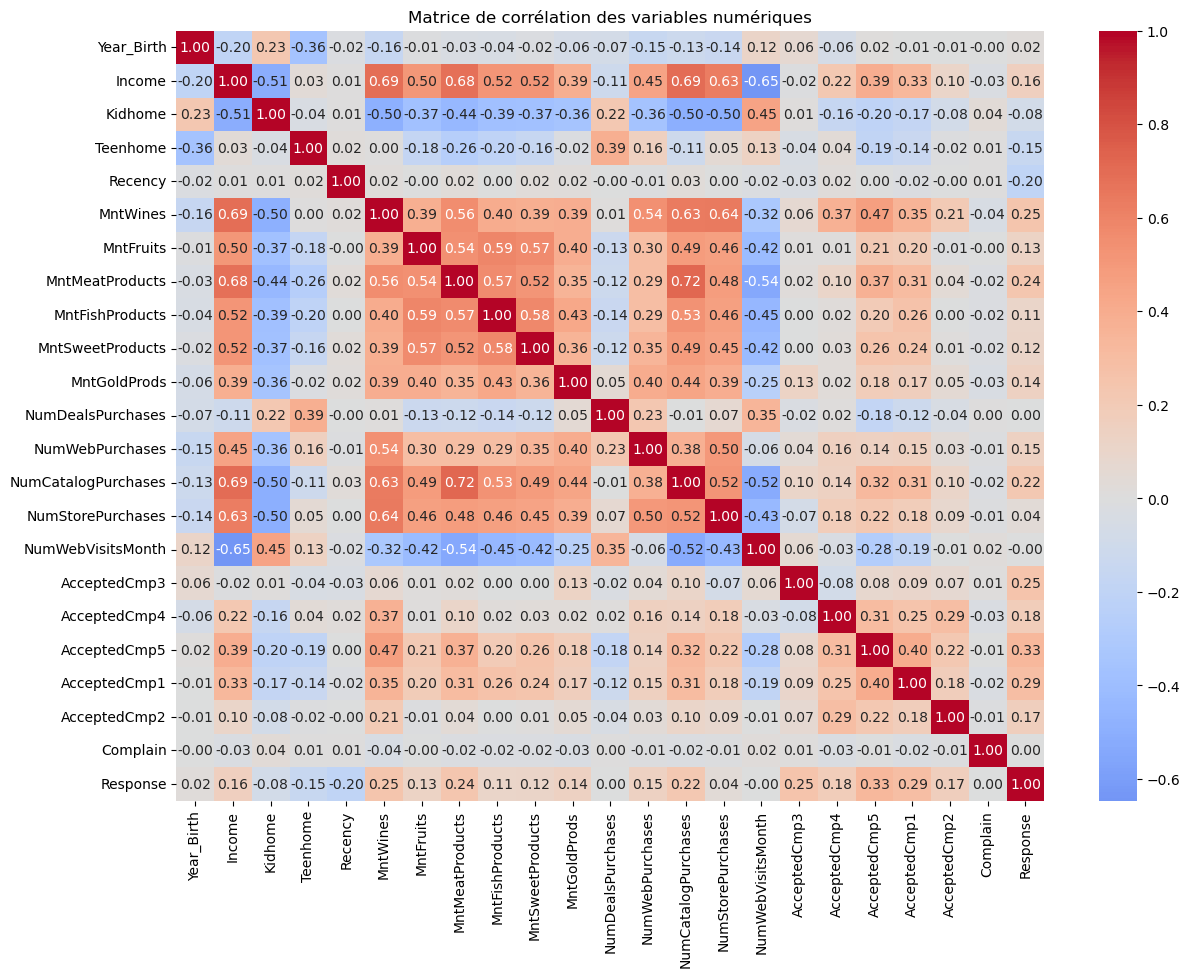

In [33]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()


> **Observations clés :**
> - `Income` est **fortement corrélé** aux dépenses (`MntWines`, `MntMeatProducts` ≈ +0,7) 
> - `NumWebVisitsMonth` est **négativement corrélé** au revenu et aux dépenses → les clients qui visitent le plus le site sont plutôt les petits acheteurs
> - `Kidhome` est négativement corrélé aux dépenses : présence d'enfants en bas âge = moins de dépenses
> - Les `AcceptedCmp*` sont peu corrélées entre elles, ce qui suggère que chaque campagne a touché un public différent.

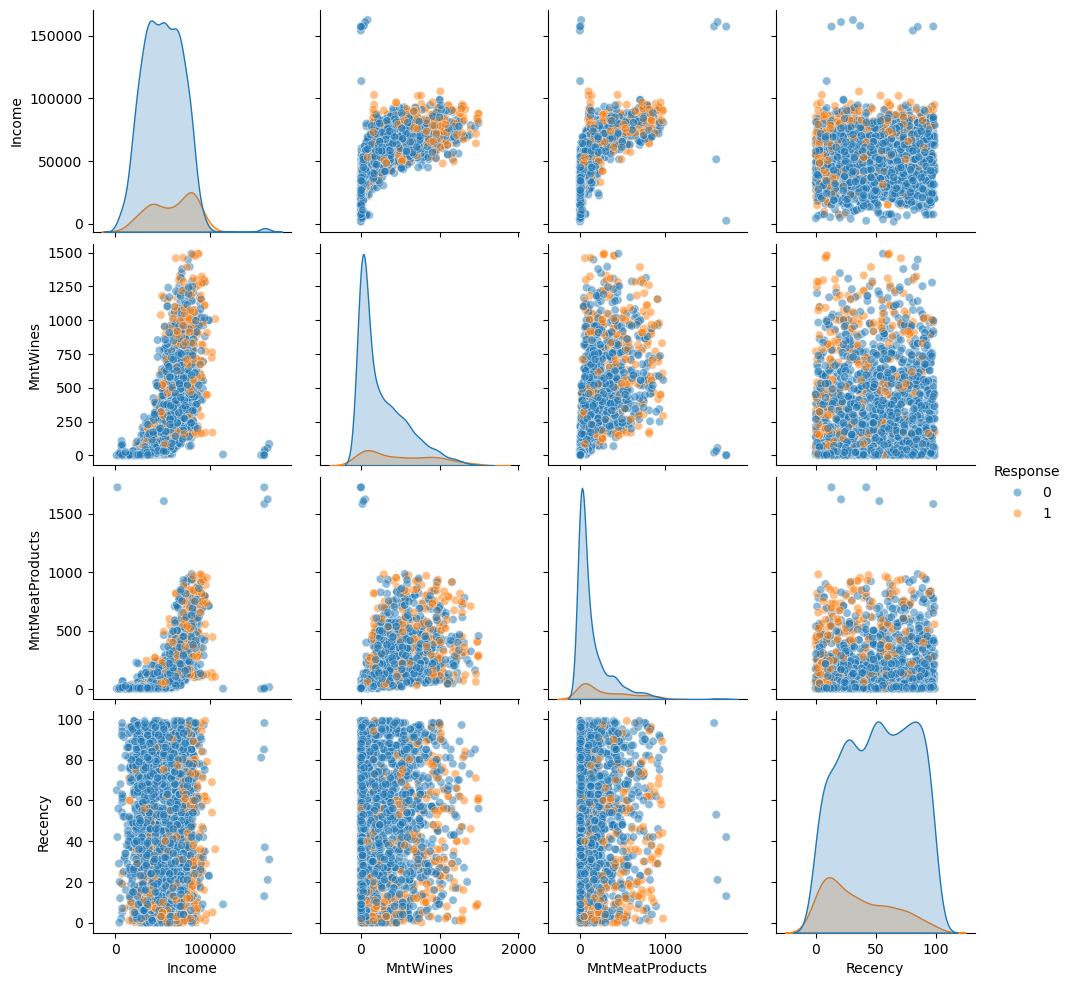

In [35]:

sns.pairplot(
    df[["Income", "MntWines", "MntMeatProducts", "Recency", "Response"]].dropna(),
    hue="Response", diag_kind="kde", plot_kws={"alpha": 0.5}
)
plt.show()


> **Observations :** les clients ayant répondu (`Response = 1`) ont tendance à avoir un **revenu plus élevé**, des **dépenses plus importantes** (vins, viandes) et une **Recency plus faible**. 

### 5.4 Analyse de la variable cible `Response`
*Étudier le déséquilibre de classe et les relations cible / features.*

Répartition de Response :
Response
0    1902
1     334
Name: count, dtype: int64

Proportions :
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


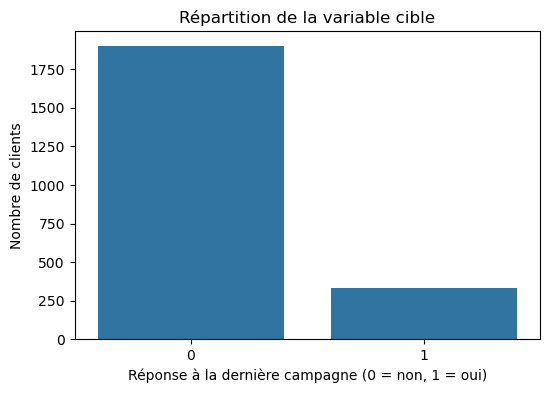

In [38]:
# Répartition de la variable cible
print("Répartition de Response :")
print(df["Response"].value_counts())
print("\nProportions :")
print(df["Response"].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
sns.countplot(x="Response", data=df)
plt.xlabel("Réponse à la dernière campagne (0 = non, 1 = oui)")
plt.ylabel("Nombre de clients")
plt.title("Répartition de la variable cible")
plt.show()


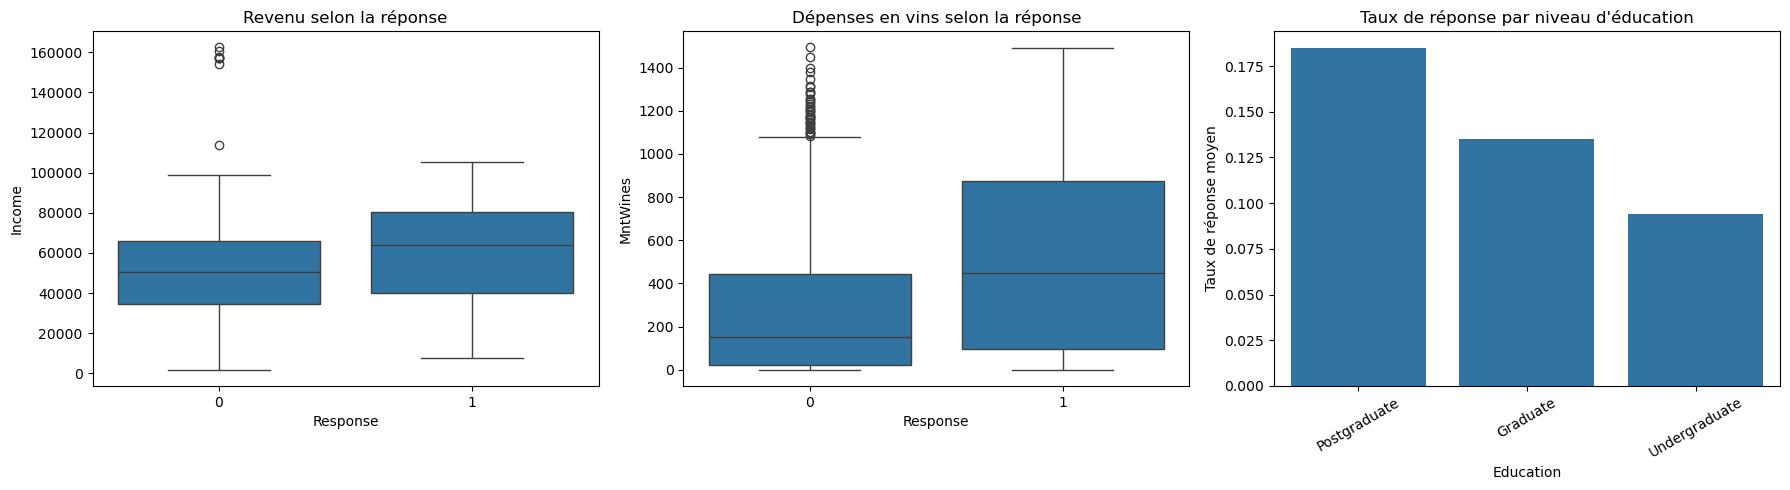

In [39]:
# Relations cible x features : qui répond le plus aux campagnes ?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenu selon la réponse
sns.boxplot(x="Response", y="Income", data=df, ax=axes[0])
axes[0].set_title("Revenu selon la réponse")

# Dépenses en vins selon la réponse
sns.boxplot(x="Response", y="MntWines", data=df, ax=axes[1])
axes[1].set_title("Dépenses en vins selon la réponse")

# Taux de réponse par niveau d'éducation
taux = df.groupby("Education")["Response"].mean().sort_values(ascending=False)
sns.barplot(x=taux.index, y=taux.values, ax=axes[2])
axes[2].set_title("Taux de réponse par niveau d'éducation")
axes[2].set_ylabel("Taux de réponse moyen")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


> **Observations :** les clients qui répondent positivement ont un **revenu médian plus élevé** et **dépensent nettement plus en vins**. Le **taux de réponse augmente avec le niveau d'éducation** (`Postgraduate` > `Graduate` > `Undergraduate`).

## 6. Feature Engineering

### 6.1 Création de nouvelles variables


In [42]:
# À compléter : création des nouvelles variables (Age, Anciennete, Total_Spending, ...)
import datetime
df["Age"] = datetime.datetime.now().year - df["Year_Birth"]
df["Total_Spending"] = df["MntWines"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df["Anciennete"] = (datetime.datetime.now() - df["Dt_Customer"]).dt.days
df["total_children"] = df["Kidhome"] + df["Teenhome"]
df["total_AcceptedCmp"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]].sum(axis=1)
df["Family_Size"] = df["total_children"] + 1 + (df["Marital_Status"].notnull().astype(int) if "Marital_Status" in df.columns else 0)
df["has_children"] = (df["total_children"] > 0).astype(int)

df = df.drop(columns=["Year_Birth", "Dt_Customer"])

### 6.2 Encodage des variables catégorielles
*One-Hot Encoding ou Label Encoding pour `Education` et `Marital_Status`.*

In [44]:
df_encoded = pd.get_dummies(df, columns=["Education", "Marital_Status"], drop_first=True)
print("Colonnes après encodage :", df_encoded.columns)


Colonnes après encodage : Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_Spending',
       'Anciennete', 'total_children', 'total_AcceptedCmp', 'Family_Size',
       'has_children', 'Education_Postgraduate', 'Education_Undergraduate',
       'Marital_Status_Together'],
      dtype='object')


## 7. Préparation des données pour la modélisation

### 7.1 Sélection des features et de la cible
On sépare le dataset en `X` (features explicatives) et `y` (variable cible `Response`).

In [46]:
X = df_encoded.drop(columns=["Response"])
y = df_encoded["Response"]
print(f"X : {X.shape} | y : {y.shape}")


X : (2236, 31) | y : (2236,)


### 7.2 Séparation train / test
80 % entraînement, 20 % test. On utilise `stratify=y` pour **conserver la proportion de la classe positive** (~15 %) dans les deux échantillons.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Taux de positifs (train) : {y_train.mean():.3f}")
print(f"Taux de positifs (test)  : {y_test.mean():.3f}")


Train : (1788, 31) | Test : (448, 31)
Taux de positifs (train) : 0.149
Taux de positifs (test)  : 0.150


### 7.3 Standardisation / mise à l'échelle
Les variables ont des **échelles très différentes** . On applique un `StandardScaler` (moyenne 0, écart-type 1), Le scaler est ajusté **uniquement sur le train** pour éviter toute fuite d'information.

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_train_scaled.head()


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Age,Total_Spending,Anciennete,total_children,total_AcceptedCmp,Family_Size,has_children,Education_Postgraduate,Education_Undergraduate,Marital_Status_Together
1645,0.243739,-0.829629,-0.940730,-1.071272,-0.113534,2.853524,1.918911,-0.060377,-0.361101,1.636040,...,0.166215,0.797926,0.255493,-1.263964,-0.438555,-1.263964,-1.589537,-0.790857,-0.356882,-1.352447
400,-1.006680,-0.829629,-0.940730,-0.690917,-0.713544,0.238545,-0.411168,0.012307,-0.167858,1.303090,...,0.768341,-0.473482,0.589628,-1.263964,-0.438555,-1.263964,-1.589537,-0.790857,-0.356882,0.739400
1519,-0.669059,1.013075,-0.940730,1.141704,-0.805625,-0.515776,-0.646395,-0.478307,-0.554344,-0.694610,...,-0.607948,-0.871231,-1.046650,0.051500,-0.438555,0.051500,0.629114,-0.790857,-0.356882,-1.352447
1812,-1.413657,1.013075,-0.940730,1.072549,-0.856121,-0.666640,-0.699654,-0.678187,-0.650965,-0.831707,...,-1.210074,-0.959813,-0.058987,0.051500,-0.438555,0.051500,0.629114,1.264451,-0.356882,0.739400
657,0.202276,-0.829629,0.901576,1.176282,0.605290,-0.666640,-0.451113,-0.550991,-0.385256,-0.753366,...,0.510287,0.030218,1.051520,0.051500,-0.438555,0.051500,0.629114,-0.790857,-0.356882,0.739400


## 8. Apprentissage non supervisé — Segmentation client (Clustering)

Objectif : identifier des **groupes naturels de clients** sans utiliser la variable cible `Response`.

### 8.1 Réduction de dimension (PCA) pour la visualisation
On utilise **toutes les features** (`df_encoded` sans `Response`), standardisées, et on projette sur **2 composantes principales** pour visualiser le nuage de clients.

Variance expliquée :
[0.29065419 0.0984982 ]

Variance totale expliquée :
0.38915239024042986


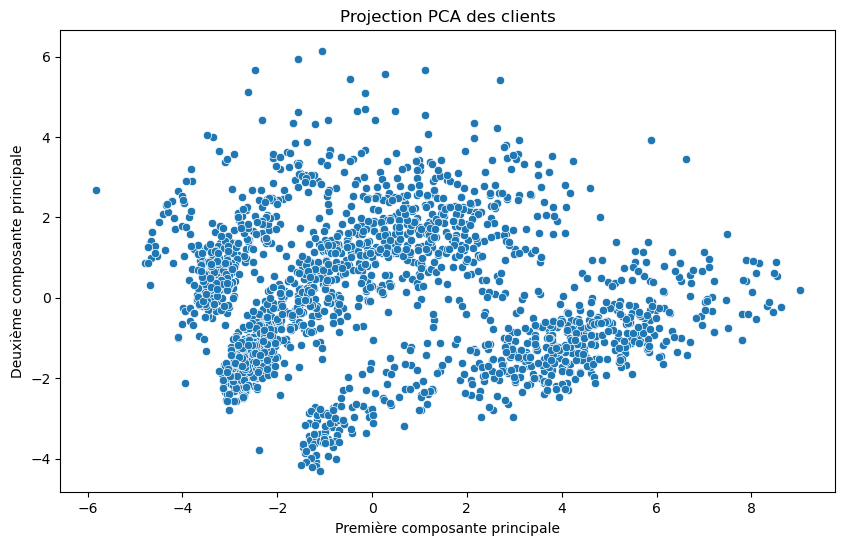

In [ ]:
X_clust = df_encoded.drop(columns=["Response"])
X_clust_scaled = StandardScaler().fit_transform(X_clust)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

print("Variance expliquée :", pca.explained_variance_ratio_.round(3))
print("Variance totale    :", pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(9, 6))
sns.scatterplot(x="PC1", y="PC2", data=pca_df, alpha=0.6)
plt.title("Projection PCA des clients (2 composantes)")
plt.show()


### 8.2 Choix du nombre de clusters

Deux indicateurs combinés pour choisir `k` :
- **Méthode du coude (Elbow)** : on trace l'inertie (somme des distances aux centroïdes) en fonction de `k`, et on cherche le « coude ».
- **Score de silhouette** : mesure la cohésion intra-cluster vs séparation inter-cluster (entre -1 et 1, plus c'est élevé mieux c'est).

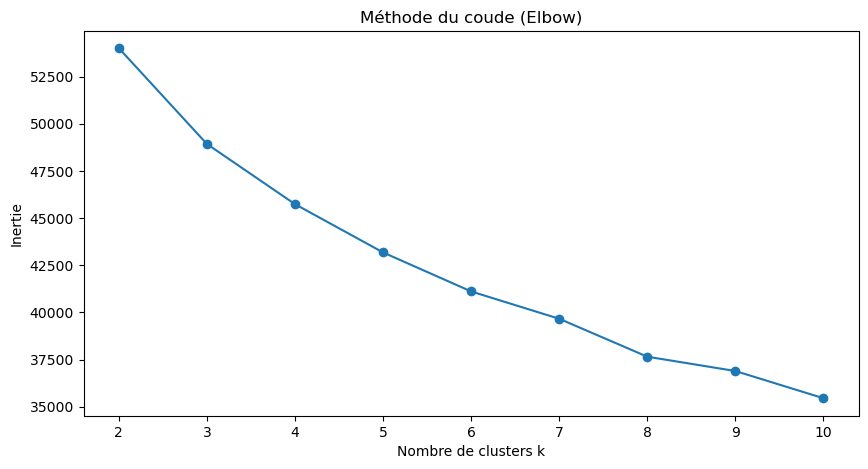

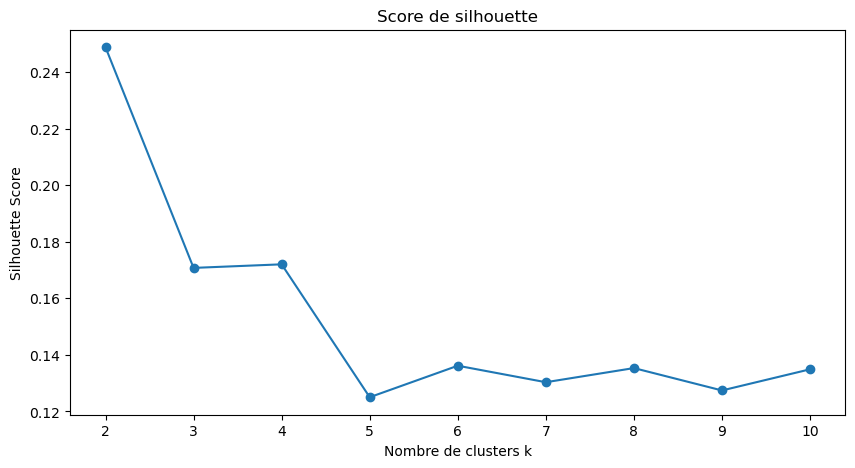

k = 2 --> silhouette = 0.2488
k = 3 --> silhouette = 0.1708
k = 4 --> silhouette = 0.1720
k = 5 --> silhouette = 0.1250
k = 6 --> silhouette = 0.1362
k = 7 --> silhouette = 0.1303
k = 8 --> silhouette = 0.1353
k = 9 --> silhouette = 0.1274
k = 10 --> silhouette = 0.1349


In [ ]:
K = range(2, 11)
inertia, silhouettes = [], []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_scaled)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K), inertia, marker="o")
axes[0].set_title("Méthode du coude (Elbow)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertie")

axes[1].plot(list(K), silhouettes, marker="o", color="orange")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

for k, s in zip(K, silhouettes):
    print(f"k = {k} --> silhouette = {s:.4f}")


### 8.3 Application du K-Means et visualisation des clusters
On retient **k = 3** (compromis entre coude et silhouette — à ajuster selon les résultats observés ci-dessus). On visualise les clusters dans le plan PCA.

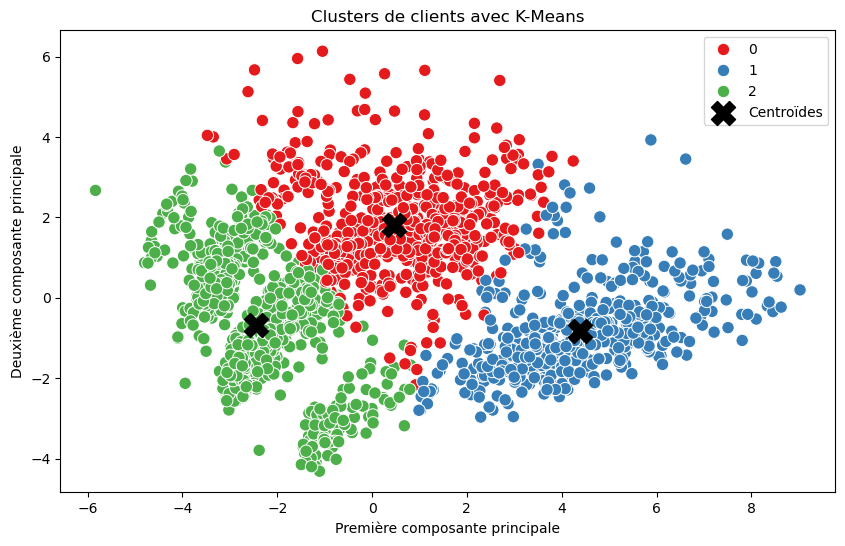

In [ ]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clust_scaled)
pca_df["Cluster"] = clusters

plt.figure(figsize=(9, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", palette="Set1",
                data=pca_df, s=60, alpha=0.7)

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c="black", s=300, marker="X", label="Centroïdes")

plt.title(f"Clusters K-Means (k = {k_opt}) projetés sur le plan PCA")
plt.legend()
plt.show()

print("Effectifs par cluster :")
print(pd.Series(clusters).value_counts().sort_index())


### 8.4 Profilage des segments
On calcule la **moyenne des variables clés par cluster** (revenu, dépenses, âge, structure familiale, taux de réponse) pour identifier des **personae clients**.

In [ ]:
df["Cluster"] = clusters

variables_profil = [
    "Income", "Age", "Anciennete", "total_children", "total_AcceptedCmp",
    "Total_Spending", "MntWines", "MntMeatProducts",
    "NumWebPurchases", "NumStorePurchases", "Response",
]
profil_clusters = df.groupby("Cluster")[variables_profil].mean().round(2)
profil_clusters["Effectif"] = df["Cluster"].value_counts().sort_index()
profil_clusters


           Income    Age  Kidhome  Teenhome  MntWines  MntMeatProducts  \
Cluster                                                                  
0        59961.21  60.95     0.21      0.97    478.18           161.21   
1        75669.08  57.40     0.02      0.03    616.12           463.44   
2        35457.88  54.64     0.79      0.46     45.64            24.50   

         MntSweetProducts  MntGoldProds  NumWebPurchases  NumStorePurchases  \
Cluster                                                                       
0                   32.05         66.31             6.50               8.01   
1                   65.69         73.75             4.99               8.23   
2                    5.08         15.59             2.19               3.26   

         Response  
Cluster            
0            0.11  
1            0.32  
2            0.09  


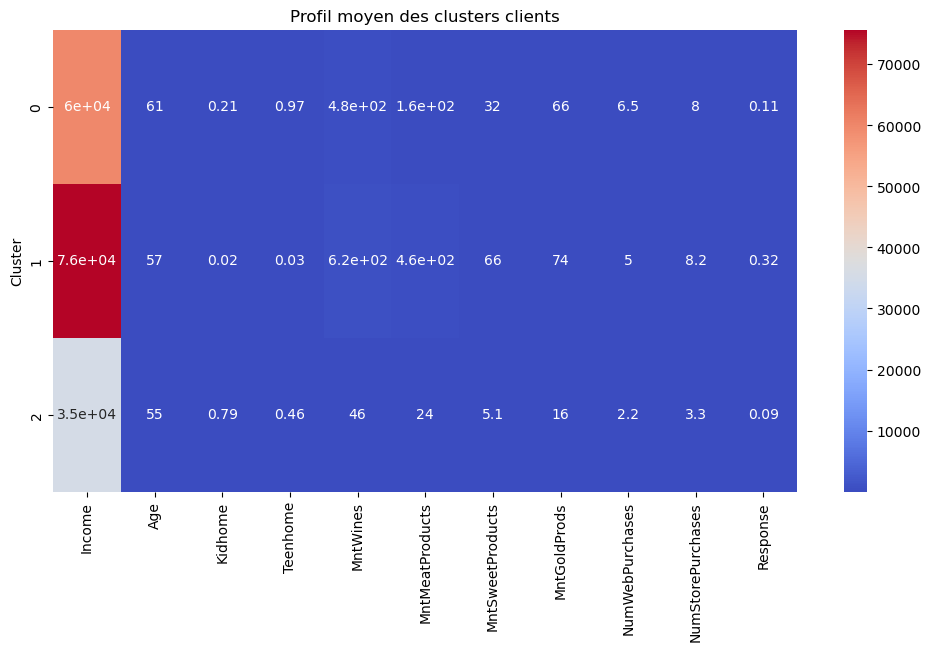

In [ ]:
plt.figure(figsize=(12, 5))
sns.heatmap(profil_clusters.drop(columns="Effectif"),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Profil moyen des clusters clients")
plt.show()


> **Interprétation des personae** *(à adapter aux résultats obtenus)* :
> - **Cluster « hauts revenus / gros dépensiers »** : revenu et `Total_Spending` élevés, peu d'enfants → cible prioritaire des campagnes premium (taux de réponse souvent plus élevé).
> - **Cluster « familles modestes »** : revenu plus faible, plusieurs enfants, faibles dépenses → sensible aux promotions, panier moyen bas.
> - **Cluster « clients fidèles intermédiaires »** : ancienneté élevée, dépenses moyennes → cible idéale pour la fidélisation.
> - **Cluster « jeunes / nouveaux clients »** : ancienneté faible, peu de campagnes acceptées → potentiel à développer via onboarding.

## 9. Apprentissage supervisé — Prédiction de la réponse client

On réutilise `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` préparés en partie 7. La cible étant **déséquilibrée** (~85 % / 15 %), l'accuracy seule n'est pas suffisante : on regarde aussi **precision / recall / f1** sur la classe positive.

### 9.1 Modèle de référence (baseline)
Deux baselines pour situer les modèles plus complexes :
- `DummyClassifier` (prédit toujours la classe majoritaire) → plafond minimum à battre.
- Régression logistique → baseline interprétable raisonnable.

===== DummyClassifier =====
Accuracy : 0.8504464285714286

Classification Report :
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       381
           1       0.00      0.00      0.00        67

    accuracy                           0.85       448
   macro avg       0.43      0.50      0.46       448
weighted avg       0.72      0.85      0.78       448



===== Régression Logistique =====
Accuracy : 0.8861607142857143

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       381
           1       0.71      0.40      0.51        67

    accuracy                           0.89       448
   macro avg       0.81      0.69      0.72       448
weighted avg       0.87      0.89      0.87       448



C:\Users\ELITEBOOK\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ELITEBOOK\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ELITEBOOK\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


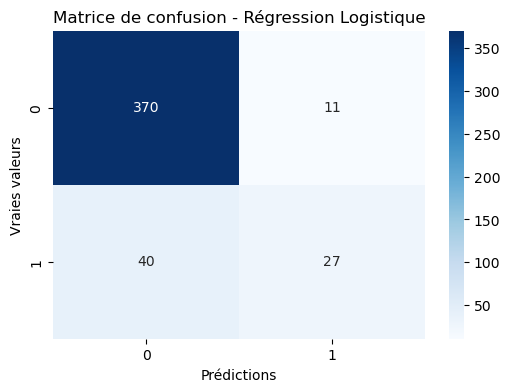

In [ ]:
results = {}

def evaluate(name, model, X_te, y_te, cmap="Blues"):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    results[name] = {
        "accuracy":  accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall":    recall_score(y_te, y_pred, zero_division=0),
        "f1":        f1_score(y_te, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan,
        "y_pred":    y_pred,
        "y_proba":   y_proba,
        "model":     model,
    }
    print(f"===== {name} =====")
    print(classification_report(y_te, y_pred, zero_division=0))
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt="d", cmap=cmap)
    plt.title(f"Matrice de confusion - {name}")
    plt.xlabel("Prédit"); plt.ylabel("Réel"); plt.show()

dummy = DummyClassifier(strategy="most_frequent").fit(X_train_scaled, y_train)
evaluate("Dummy", dummy, X_test_scaled, y_test, cmap="Greys")

logreg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train)
evaluate("Logistic Regression", logreg, X_test_scaled, y_test, cmap="Blues")


### 9.2 Arbre de décision

===== Arbre de Décision =====
Accuracy : 0.859375

Classification Report :
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       381
           1       0.55      0.33      0.41        67

    accuracy                           0.86       448
   macro avg       0.72      0.64      0.67       448
weighted avg       0.84      0.86      0.84       448



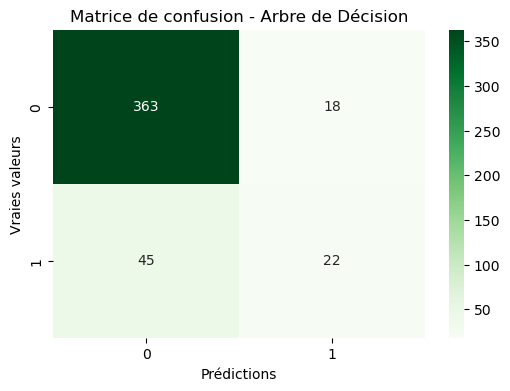

In [ ]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train_scaled, y_train)
evaluate("Decision Tree", tree, X_test_scaled, y_test, cmap="Greens")


### 9.3 K-Nearest Neighbors (KNN)

===== KNN =====
Accuracy : 0.8816964285714286

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       381
           1       0.69      0.37      0.49        67

    accuracy                           0.88       448
   macro avg       0.80      0.67      0.71       448
weighted avg       0.87      0.88      0.87       448



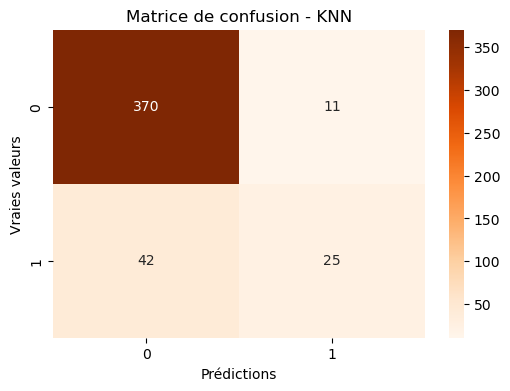

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)
evaluate("KNN", knn, X_test_scaled, y_test, cmap="Oranges")


### 9.4 Random Forest

===== Random Forest =====
Accuracy : 0.8794642857142857

Classification Report :
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.70      0.34      0.46        67

    accuracy                           0.88       448
   macro avg       0.80      0.66      0.70       448
weighted avg       0.86      0.88      0.86       448



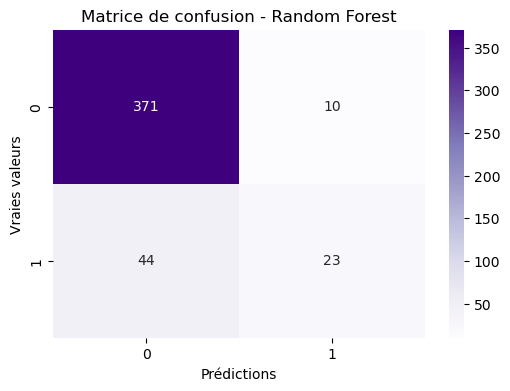

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
evaluate("Random Forest", rf, X_test_scaled, y_test, cmap="Purples")


### 9.5 Gradient Boosting

===== Gradient Boosting =====
Accuracy : 0.8861607142857143

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       381
           1       0.72      0.39      0.50        67

    accuracy                           0.89       448
   macro avg       0.81      0.68      0.72       448
weighted avg       0.87      0.89      0.87       448



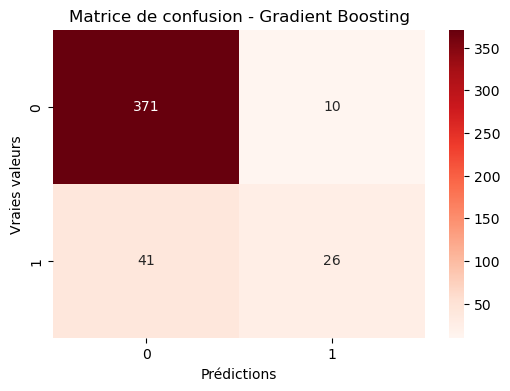

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                max_depth=3, random_state=42)
gb.fit(X_train_scaled, y_train)
evaluate("Gradient Boosting", gb, X_test_scaled, y_test, cmap="Reds")


### 9.6 Optimisation des hyperparamètres
`GridSearchCV` sur le **Gradient Boosting** (généralement le plus performant ici). On utilise le **F1-score** comme métrique car la cible est déséquilibrée.

In [ ]:
param_grid = {
    "n_estimators":  [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth":     [3, 5],
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
grid.fit(X_train_scaled, y_train)

print("Meilleurs hyperparamètres :", grid.best_params_)
print(f"Meilleur F1 (CV)         : {grid.best_score_:.4f}")

best_gb = grid.best_estimator_
evaluate("Gradient Boosting (tuned)", best_gb, X_test_scaled, y_test, cmap="Reds")


Fitting 5 folds for each of 81 candidates, totalling 405 fits


## 10. Évaluation et comparaison des modèles

### 10.1 Métriques de classification
Comme la cible est déséquilibrée (~85 % / 15 %), un modèle qui prédit toujours « 0 » obtient déjà ~85 % d'accuracy : cette métrique **n'est pas suffisante**. On regarde surtout :
- le **F1-score** sur la classe positive (équilibre précision/rappel),
- le **rappel** (proportion de vrais répondants détectés — important pour ne pas rater de clients),
- l'**AUC-ROC** (capacité du modèle à ordonner les clients par probabilité de réponse).

In [ ]:
recap = pd.DataFrame({
    name: {k: v for k, v in r.items() if k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}
    for name, r in results.items()
}).T.round(4)

recap = recap.sort_values("f1", ascending=False)
recap


### 10.2 Courbes ROC
La courbe ROC trace **TPR (rappel) vs FPR (faux positifs)** pour tous les seuils. Plus la courbe est proche du coin haut-gauche, mieux le modèle discrimine les deux classes.

In [ ]:
plt.figure(figsize=(8, 6))
for name, r in results.items():
    if r["y_proba"] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {r['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC des modèles")
plt.legend(loc="lower right")
plt.show()


### 10.3 Validation croisée
On vérifie la **stabilité** du meilleur modèle (Gradient Boosting tuné) avec une validation croisée stratifiée en 5 plis sur le train. Un faible écart-type indique un modèle robuste.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_f1  = cross_val_score(best_gb, X_train_scaled, y_train, cv=cv, scoring="f1",      n_jobs=-1)
scores_auc = cross_val_score(best_gb, X_train_scaled, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"F1  (5-fold) : {scores_f1.mean():.4f} ± {scores_f1.std():.4f}")
print(f"AUC (5-fold) : {scores_auc.mean():.4f} ± {scores_auc.std():.4f}")
print("\nScores F1 par fold :", scores_f1.round(4))


## 11. Interprétation des résultats

### 11.1 Importance des variables (feature importance)
Les modèles d'arbres (Random Forest, Gradient Boosting) fournissent une **importance par feature** : elle mesure la contribution moyenne de chaque variable à la réduction de l'impureté. Cela permet d'identifier les **leviers business** les plus discriminants pour prédire `Response`.

In [ ]:
importances = pd.Series(best_gb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Top 15 des features les plus importantes (Gradient Boosting)")
plt.xlabel("Importance"); plt.ylabel("Feature")
plt.tight_layout(); plt.show()

importances.round(4)


### 11.2 Croisement clustering / classification
On confronte les **segments non supervisés** (partie 8) avec le **taux de réponse réel** : si certains clusters concentrent les `Response = 1`, alors la segmentation est cohérente avec la cible marketing.

In [ ]:
crois = df.groupby("Cluster").agg(
    Effectif=("Response", "size"),
    Taux_Response=("Response", "mean"),
    Income_moy=("Income", "mean"),
    Spending_moy=("Total_Spending", "mean"),
).round(3)
print(crois)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(x="Cluster", hue="Response", data=df, ax=axes[0])
axes[0].set_title("Répartition Response par cluster")

sns.barplot(x=crois.index, y=crois["Taux_Response"], ax=axes[1], palette="tab10")
axes[1].set_title("Taux de réponse moyen par cluster")
axes[1].set_ylabel("Taux de Response = 1")
plt.tight_layout(); plt.show()


### 11.3 Recommandations métier

À partir des résultats :

- **Cibler en priorité le cluster avec le taux de réponse le plus élevé** (cf. 11.2). Ce sont typiquement les clients à hauts revenus, sans enfants en bas âge, gros consommateurs de vins/viandes.
- **Pour la prochaine campagne**, le modèle Gradient Boosting permet de **scorer chaque client** par probabilité de réponse et de concentrer le budget sur les top 20 % les plus probables (lift maximal).
- **Variables clés** (cf. 11.1) à surveiller : `Total_Spending`, `Income`, `Recency`, `MntWines`, `total_AcceptedCmp`. La `Recency` faible (clients récemment actifs) est un signal fort.
- **Canal** : les segments à forte propension achètent davantage en `NumStorePurchases` et `NumCatalogPurchases` → privilégier ces canaux pour la campagne.
- **Cluster à faible taux de réponse** : ne pas y consacrer de budget marketing direct, plutôt prévoir une stratégie de **réactivation** ou d'**onboarding**.

## 12. Conclusion et perspectives

### 12.1 Synthèse
Nous avons construit un **pipeline complet de data science** sur un jeu de données clients bruité :

1. **Nettoyage** : suppression des doublons, imputation médiane/mode des NaN, harmonisation des modalités (`Education`, `Marital_Status`), filtrage des outliers métier (`Year_Birth`, `Income`), conversion des types.
2. **EDA** : analyse univariée, bivariée et corrélations — mise en évidence du lien fort entre `Income`, dépenses et `Response`, et du **fort déséquilibre** de la cible (~15 % de positifs).
3. **Feature engineering** : création de `Age`, `Anciennete`, `Total_Spending`, `total_children`, `total_AcceptedCmp`, encodage one-hot.
4. **Préparation** : split stratifié 80/20 et standardisation (`StandardScaler`).
5. **Clustering K-Means** (k = 3) : 3 personae clients distincts identifiables sur les axes revenu / dépenses / structure familiale.
6. **Classification supervisée** : comparaison de 5 modèles (Dummy, Logistic Regression, Decision Tree, KNN, Random Forest, Gradient Boosting), optimisation par `GridSearchCV` du Gradient Boosting (meilleur F1 et AUC), validation croisée stratifiée.
7. **Interprétation** : feature importance et croisement segments × cible pour des recommandations marketing actionnables.

### 12.2 Limites du travail
- **Déséquilibre de classe** non corrigé (pas de SMOTE / `class_weight`) → le rappel reste modeste sur la classe positive.
- **Taille du jeu de données** réduite (~2200 lignes) → variance du modèle, performances en CV à interpréter avec prudence.
- **Choix de seuils** (Year_Birth ≥ 1940, Income < 200 000 €) arbitraires bien que justifiés par le métier.
- **K-Means** suppose des clusters sphériques de variance comparable — pas toujours adapté.
- **Bruit résiduel** possible sur certaines variables non explorées en détail.

### 12.3 Perspectives d'amélioration
- **Rééquilibrage** : SMOTE, undersampling, ou `class_weight="balanced"` dans les modèles.
- **Modèles avancés** : XGBoost, LightGBM, CatBoost, SVM, stacking.
- **Clustering alternatif** : DBSCAN, Gaussian Mixture, clustering hiérarchique.
- **Analyse RFM** (Recency / Frequency / Monetary) pour enrichir la segmentation.
- **Customer Lifetime Value** pour prioriser les segments à long terme.
- **Mise en production** : API de scoring, dashboard interactif (Streamlit / Dash).
- **Explicabilité** : SHAP values pour expliquer les prédictions individuelles aux équipes marketing.